# [DIS 1] ReLUs and Neural Network Intuition

**If you are running on a local anaconda install, you will need to install pytorch with the command**
```sh
conda install pytorch -c pytorch
```

<!-- #TODO(krishna) : add wandb integration -->
<!-- You should immediately run all the cells up through 'Train all layers' since training the networks takes a long time. While you wait you can return to the theory portion of this discussion and work on the backpropagation problem. -->

If you are running on Colab, run the cell below and ensure that ``helpers.py q_relu_vis.ipynb`` is outputted

In [1]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import numpy as np
import copy
import time
from ipywidgets import fixed, interactive, widgets 

from helpers import *

%matplotlib inline

# Generate Training and Test Data

We are using piecewise linear function. Our training data has added noise $y = f(x) + \epsilon,\, \epsilon \sim \mathcal{N}(0, \sigma^2)$. The test data is noise free.

_Once you have gone through the discussion once you may wish to adjust the number of training samples and noise variance to see how gradient descent behaves under the new conditions._

In [2]:
f_type = 'piecewise_linear'

def f_true(X, f_type):
    if f_type == 'sin(20x)':
        return np.sin(20 * X[:,0])
    else:
        TenX = 10 * X[:,0]
        _ = 12345
        return (TenX - np.floor(TenX)) * np.sin(_ * np.ceil(TenX)) - (TenX - np.ceil(TenX)) * np.sin(_ * np.floor(TenX)) 
    
n_features = 1
n_samples = 200
sigma = 0.1
rng = np.random.RandomState(1)

# Generate train data
X = np.sort(rng.rand(n_samples, n_features), axis=0)
y = f_true(X, f_type) + rng.randn(n_samples) * sigma

# Generate NOISELESS test data
X_test = np.concatenate([X.copy(), np.expand_dims(np.linspace(0., 1., 1000), axis=1)])
X_test = np.sort(X_test, axis=0)
y_test = f_true(X_test, f_type)

# Define the Neural Networks

We will learn the piecewise linear target function using a simple 1-hidden layer neural network with ReLU non-linearity, defined by
$$ \hat{y} = \mathbf{W}^{(2)} \Phi \left( \mathbf{W}^{(1)} x + \mathbf{b}^{(1)} \right) + \mathbf{b}^{(2)} $$
where $\Phi(x) = ReLU(x)$ and superscripts refer to indices, not the power operator.

We will also create two SGD optimizers to allow us to choose whether to train all parameters or only the linear output layer's parameters. Note that we use separate learning rates for the two version of training. There is too much variance in the gradients when training all layers to use a large learning rate, so we have to decrease it.

We will modify the default initialization of the biases so that the ReLU elbows are all inside the region we are interested in.

We create several versions of this network with varying widths to explore how hidden layer width impacts learning performance.

_Once you have gone through the discussion once you may wish to train networks with even larger widths to see how they behave under the three different training paradigms in this notebook._

In [3]:
# Don't rerun this cell after training or you will lose all your work
nets_by_size = {}

In [4]:
widths = [10, 20, 40]
for width in widths:
    # Define a 1-hidden layer ReLU nonlinearity network
    net = nn.Sequential(nn.Linear(1, width),
                        nn.ReLU(),
                        nn.Linear(width, 1))
    loss = nn.MSELoss()
    # Get trainable parameters
    weights_all = list(net.parameters())
    #!weight[0] contains the weights of fcl1 --> (width, 1)
    #!weight[1] contains the bias of fcl1 --> (width,)
    #!then fcl2 is the same
    # Get the output weights alone
    weights_out = weights_all[2:]

    #! relu is applied on (wx + b) --> point x where we reach RELU elbow (where it goes form 0 to linear positive) is wx + b = 0 -> x = -b/w
    # Adjust initial biases so elbows are in [0,1]
    elbows = np.sort(np.random.rand(width)) #!random elbows in [0,1]
#     print("Elbows located at:")
#     print(elbows)
    new_biases = -elbows * to_numpy(weights_all[0]).ravel() #! since, as we saw, x = -b/w --> to fix elbow in the random 'e' isntead of 'x' --> b = -we
    weights_all[1].data = to_torch(new_biases)
    # Create SGD optimizers for outputs alone and for all weights
    lr_out = 0.2
    lr_all = 0.02
    opt_all = torch.optim.SGD(params=weights_all, lr=lr_all) #!update all, elbows can move (since biases moves)
    opt_out = torch.optim.SGD(params=weights_out, lr=lr_out) #update obly last layer
    # Save initial state for comparisons
    initial_weights = copy.deepcopy(net.state_dict())
    # print("Initial Weights", initial_weights)
    nets_by_size[width] = {'net': net, 'opt_all': opt_all, 
                           'opt_out': opt_out, 'init': initial_weights}

In [5]:
nets_by_size

{10: {'net': Sequential(
    (0): Linear(in_features=1, out_features=10, bias=True)
    (1): ReLU()
    (2): Linear(in_features=10, out_features=1, bias=True)
  ),
  'opt_all': SGD (
  Parameter Group 0
      dampening: 0
      differentiable: False
      foreach: None
      fused: None
      lr: 0.02
      maximize: False
      momentum: 0
      nesterov: False
      weight_decay: 0
  ),
  'opt_out': SGD (
  Parameter Group 0
      dampening: 0
      differentiable: False
      foreach: None
      fused: None
      lr: 0.2
      maximize: False
      momentum: 0
      nesterov: False
      weight_decay: 0
  ),
  'init': OrderedDict([('0.weight',
                tensor([[-0.9369],
                        [ 0.2045],
                        [ 0.9561],
                        [ 0.5582],
                        [-0.2064],
                        [ 0.5061],
                        [-0.3078],
                        [ 0.1710],
                        [-0.8385],
                        [ 0.55

## Visualize the starting ReLU corners & slopes, and total function

The dashed lines represent the output of an individual ReLU function in the hidden layer for an $x$ input passed through the first linear layer. The gray points mark the elbows of the ReLU functions where their output becomes non-zero.

Width 10


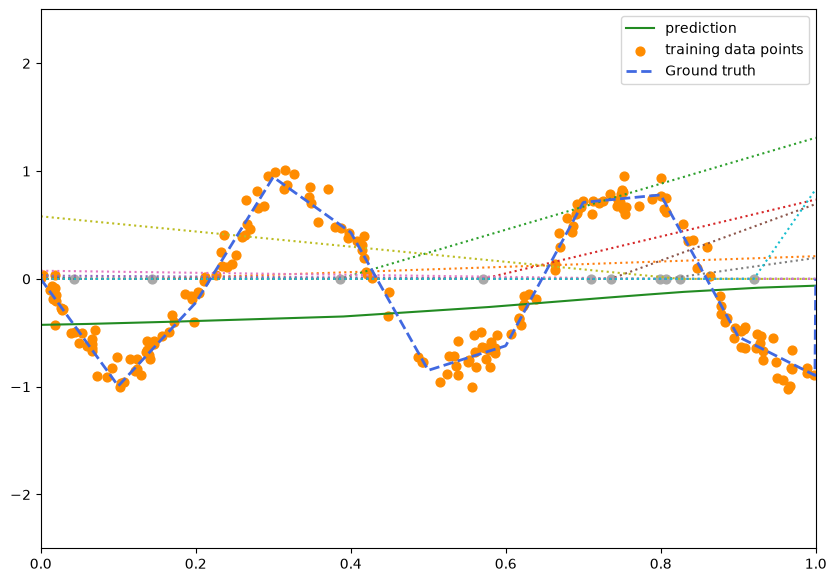

Width 20


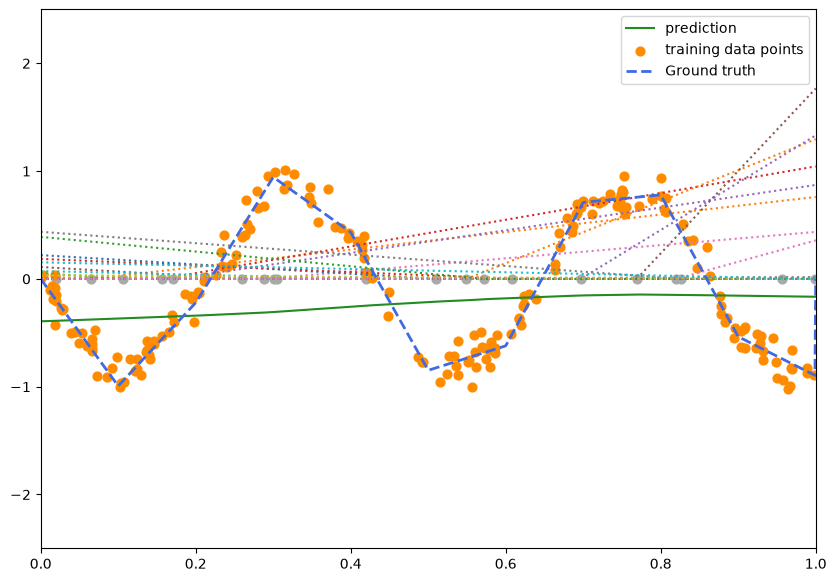

Width 40


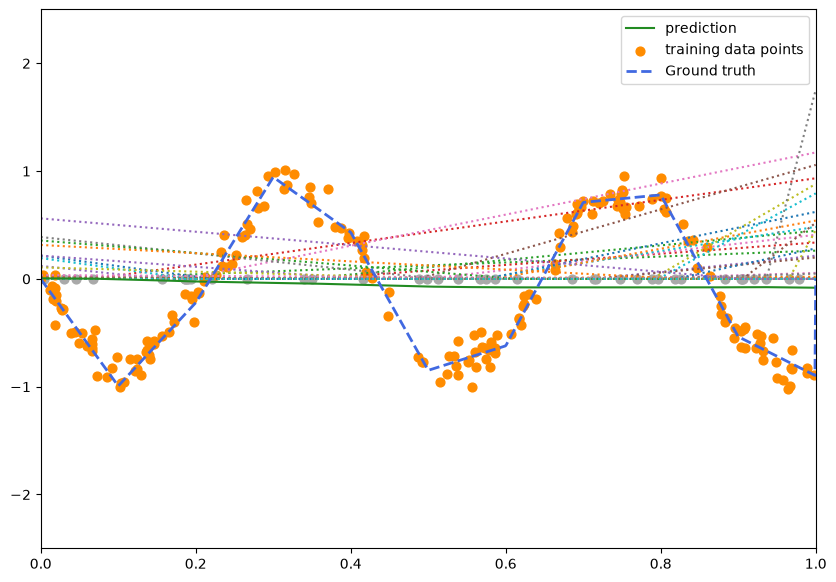

In [6]:
for w in widths:
    net = nets_by_size[w]['net']
    print("Width", w)
    plot_update(X, y, X_test, y_test, net)

# Train all the networks now - this will take a while!
You can expect training to take between 5 and 10 minutes depending on whether you run locally or on Colab and how heavily loaded Colab is at the moment.

## Train only the output layer

----------------------------------------
Width 10
SGD Iteration 10000
SGD Iteration 20000
SGD Iteration 30000
SGD Iteration 40000
SGD Iteration 50000
SGD Iteration 60000
SGD Iteration 70000
SGD Iteration 80000
SGD Iteration 90000
SGD Iteration 100000
SGD Iteration 110000
SGD Iteration 120000
SGD Iteration 130000
SGD Iteration 140000
SGD Iteration 150000
Width 10


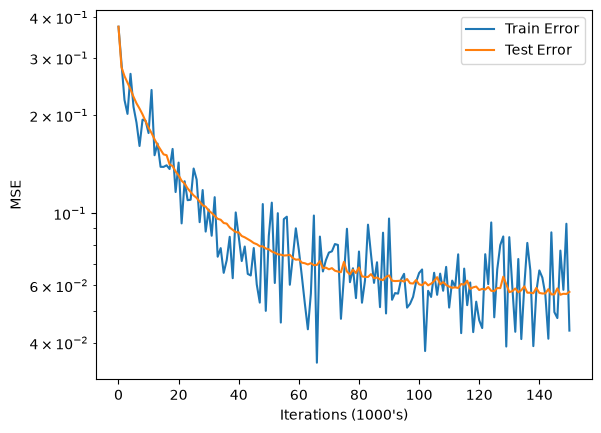

Elapsed time 0.1 minutes
----------------------------------------
Width 20
SGD Iteration 10000
SGD Iteration 20000
SGD Iteration 30000
SGD Iteration 40000
SGD Iteration 50000
SGD Iteration 60000
SGD Iteration 70000
SGD Iteration 80000
SGD Iteration 90000
SGD Iteration 100000
SGD Iteration 110000
SGD Iteration 120000
SGD Iteration 130000
SGD Iteration 140000
SGD Iteration 150000
Width 20


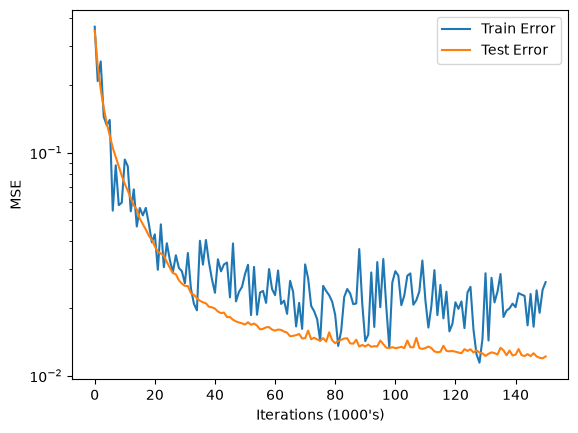

Elapsed time 0.3 minutes
----------------------------------------
Width 40
SGD Iteration 10000
SGD Iteration 20000
SGD Iteration 30000
SGD Iteration 40000
SGD Iteration 50000
SGD Iteration 60000
SGD Iteration 70000
SGD Iteration 80000
SGD Iteration 90000
SGD Iteration 100000
SGD Iteration 110000
SGD Iteration 120000
SGD Iteration 130000
SGD Iteration 140000
SGD Iteration 150000
Width 40


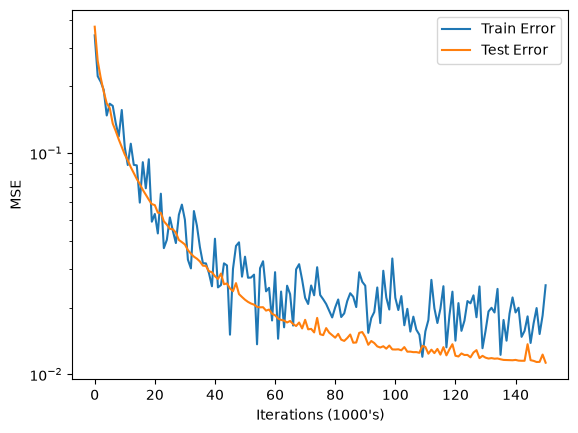

Elapsed time 0.4 minutes
----------------------------------------
Trained output layer in 0.4 minutes


In [7]:
n_steps = 150000
save_every = 1000
t0 = time.time()
for w in widths:
    print("-"*40)
    print("Width", w)
    net = nets_by_size[w]['net']
    opt_out = nets_by_size[w]['opt_out']
    initial_weights = nets_by_size[w]['init']
    history_output = train_network(X, y, X_test, y_test, 
                            net, optim=opt_out, 
                            n_steps=n_steps, save_every=save_every, 
                            initial_weights=initial_weights,
                            verbose=False)
    nets_by_size[w]['hist_out'] = history_output
    print("Width", w)
    plot_test_train_errors(history_output)
    print("Elapsed time %.1f minutes" % ((time.time() - t0) / 60))
t1 = time.time()
print("-"*40)
print("Trained output layer in %.1f minutes" % ((t1 - t0) / 60))

## Train all layers

----------------------------------------
Width 10
SGD Iteration 10000
SGD Iteration 20000
SGD Iteration 30000
SGD Iteration 40000
SGD Iteration 50000
SGD Iteration 60000
SGD Iteration 70000
SGD Iteration 80000
SGD Iteration 90000
SGD Iteration 100000
SGD Iteration 110000
SGD Iteration 120000
SGD Iteration 130000
SGD Iteration 140000
SGD Iteration 150000
Width 10


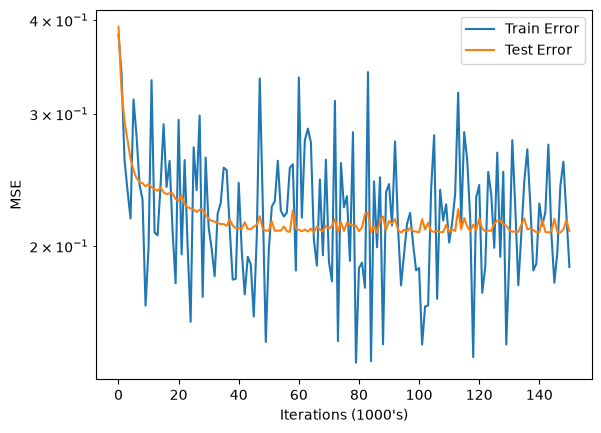

----------------------------------------
Width 20
SGD Iteration 10000
SGD Iteration 20000
SGD Iteration 30000
SGD Iteration 40000
SGD Iteration 50000
SGD Iteration 60000
SGD Iteration 70000
SGD Iteration 80000
SGD Iteration 90000
SGD Iteration 100000
SGD Iteration 110000
SGD Iteration 120000
SGD Iteration 130000
SGD Iteration 140000
SGD Iteration 150000
Width 20


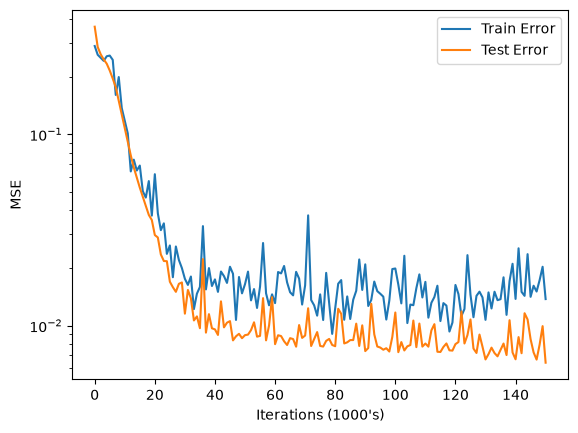

----------------------------------------
Width 40
SGD Iteration 10000
SGD Iteration 20000
SGD Iteration 30000
SGD Iteration 40000
SGD Iteration 50000
SGD Iteration 60000
SGD Iteration 70000
SGD Iteration 80000
SGD Iteration 90000
SGD Iteration 100000
SGD Iteration 110000
SGD Iteration 120000
SGD Iteration 130000
SGD Iteration 140000
SGD Iteration 150000
Width 40


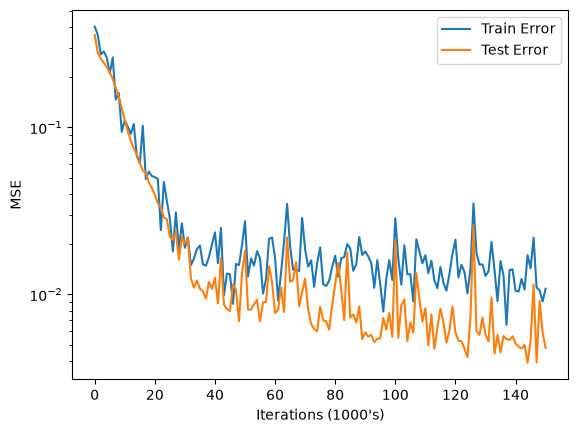

----------------------------------------
Trained all layers in 0.4 minutes


In [8]:
n_steps = 150000
save_every = 1000
t0 = time.time()
for w in widths:
    print("-"*40)
    print("Width", w)
    net = nets_by_size[w]['net']
    opt_all = nets_by_size[w]['opt_all']
    initial_weights = nets_by_size[w]['init']
    history_all = train_network(X, y, X_test, y_test, 
                            net, optim=opt_all, 
                            n_steps=n_steps, save_every=save_every, 
                            initial_weights=initial_weights,
                            verbose=False)
    nets_by_size[w]['hist_all'] = history_all
    print("Width", w)
    plot_test_train_errors(history_all)
t1 = time.time()
print("-"*40)
print("Trained all layers in %.1f minutes" % ((t1 - t0) / 60))

### Train and Test Error
In the train and test error plots, you should observe that, after sufficient training, the test error is consistently lower than the train error. Normally we expect the opposite to happen. **What is causing test error to be lower than train error?**

**This is because we add RANDOM NOISE to the training data, making the learning objective nonlinear, more than a single ReLU can afford, so error is high. On the other hand test samples are noise-free --> the learning function is then linear and the network performs better.**

# Learn the Output Layer Using Ridge Regression

We can treat the output of the hidden layer as a featurization of $x$ and use ridge regression to choose weights for the output layer instead of iterating with SGD. We have set up the infrastructure to extract the featurization of the training data and write your learned coefficients back into the network. You will **perform ridge regression with the hidden layer featurization with your choice of regularization parameter $\lambda$** and compare the result with networks learned by gradient descent.

**Learn the last layer weights with ridge regression for each network width and compare the shape of the learned functions, test error, and best regularization coefficients.**

You don't need to rigorously choose the regularization coefficient through cross-validation, but you should at least explore a range of values and pick a reasonable value.

In [9]:
nets_by_size

{10: {'net': Sequential(
    (0): Linear(in_features=1, out_features=10, bias=True)
    (1): ReLU()
    (2): Linear(in_features=10, out_features=1, bias=True)
  ),
  'opt_all': SGD (
  Parameter Group 0
      dampening: 0
      differentiable: False
      foreach: None
      fused: None
      lr: 0.02
      maximize: False
      momentum: 0
      nesterov: False
      weight_decay: 0
  ),
  'opt_out': SGD (
  Parameter Group 0
      dampening: 0
      differentiable: False
      foreach: None
      fused: None
      lr: 0.2
      maximize: False
      momentum: 0
      nesterov: False
      weight_decay: 0
  ),
  'init': OrderedDict([('0.weight',
                tensor([[-0.9369],
                        [ 0.2045],
                        [ 0.9561],
                        [ 0.5582],
                        [-0.2064],
                        [ 0.5061],
                        [-0.3078],
                        [ 0.1710],
                        [-0.8385],
                        [ 0.55

Learned coeffs: [ -4.02390096  -3.0718974    4.06417035  14.68276093  17.56364772
  -7.79577245 -13.01967915 -18.40897055  -8.24219843  18.70399283
  -4.04045992 -23.69703406 -80.18941565  47.84623411  -6.66000381
   9.48871447   8.1978363    9.87639167  -5.14728927  -6.0725474
   6.22072013  13.28075655   5.19153141 -40.86906932 -21.71965162
 -16.97233101   1.44794065   4.88906524   6.36017811 -24.41686204
   6.20029709 -10.98855447  22.97796123   3.16629162   1.85520534
  25.74766088 -20.05044502  -2.93446519  25.39252699  -0.62676007
   3.02681057]


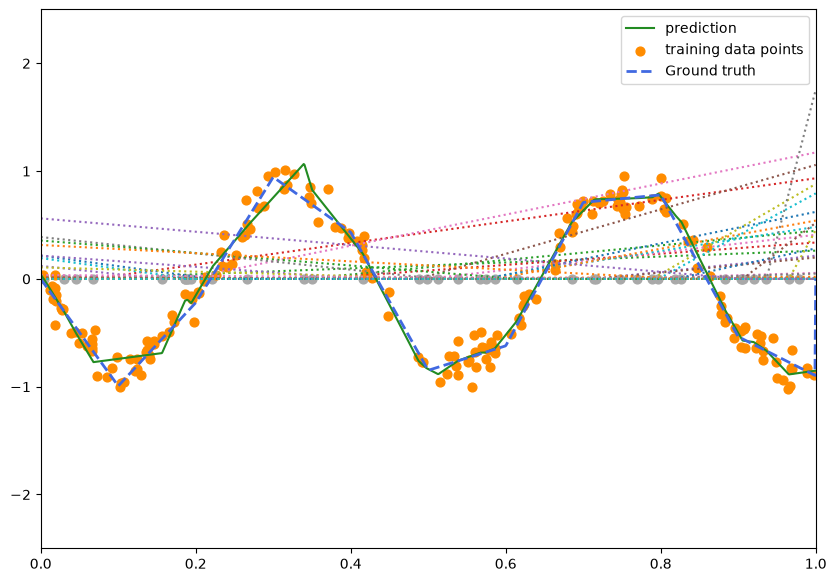

Test Error: 0.005973296094719434


In [23]:
width = 40 # Options are 10, 20, 40
# Reinititalize net
net = nets_by_size[width]['net']
initial_weights = nets_by_size[width]['init']
net.load_state_dict(initial_weights)

# Featurize x using the hidden layer
W1 = initial_weights['0.weight']
b1 = initial_weights['0.bias']
Xnew = to_torch(X) @ W1.T + b1[None, :]
Xnew = to_numpy(nn.functional.relu(Xnew))
# Add the bias term
tmp = np.ones((Xnew.shape[0], width + 1))
tmp[:, :-1] = Xnew
Xnew = tmp




# Store the learned coefficients in a width+1 size array called 'coeffs'
### start last_layer_rr ###

# we want
# beta = [w1, ..., w_width, bias]
#that minimizes ||X_new*beta-y||_2^2 + lambda * ||beta||_2^2.
#that is
#beta = (X^T X + lambda I)^-1 X^T y
lambd = 1e-5

A = Xnew.T @ Xnew + lambd * np.eye(width + 1)
b = Xnew.T @ y

coeffs = np.linalg.solve(A, b)
print("Learned coeffs:", coeffs)
### end last_layer_rr ###





# Set the output layer parameters to the learned coefficients
bias = to_torch(np.array(coeffs[-1]))
w = to_torch(coeffs[:-1].reshape(1, width))
all_params = list(net.parameters())
all_params[-1].data = bias
all_params[-2].data = w

# Test with learned output layer
plot_update(X, y, X_test, y_test, net)
test_mse = np.mean((to_numpy(net(to_torch(X_test))).ravel() - y_test) ** 2)
print("Test Error:", test_mse)

**The learned function is piecewise linear, since the hidden ReLU units introduce a set of elbows and the output layer forms a linear combination of these features. With a small width, there are only a few elbows, so the model gives a coarse approximation of the target and tends to underfit. As the width increases, the network has more ReLU features and therefore more linear segments, allowing it to follow the ground-truth function more closely. Consequently, the test error generally decreases as width increases, although after sufficient width the improvement becomes smaller and additional capacity may start fitting noise rather than the underlying function.**

Per generare output, dopo hidden layer attivato da relu (ogni neurone genera h1(x)), si combinano tutte le hidden features:

```math
\hat y(x)=b_{\text{out}}+a_1h_1(x)+\cdots+a_wh_w(x).
```

Ma alcune in quel punto valgono zero, altre stanno contribuendo con una retta.
Se avessi w = 3 ReLU (tra le `w = width` hidden features attivate) con elbows (calcolati su input x, non su hidden feature z = Wx + b):

```math
x_1=0.2,\qquad x_2=0.5,\qquad x_3=0.8.
```

quindi se entra x tra 0 e 0.2 --> nessuna e attiva:

```math
\hat y(x)=b. --> costante
```

Tra 0.2 e 0.5, entra la prima:

```math
\hat y(x)
=
b+a_1(w_1x+b_1).
```

Questa è una retta con slope

```math
a_1w_1. 
```
--> primo__slope


A x=0.5 si attiva anche la seconda:

```math
\hat y(x)
=
b+
a_1(w_1x+b_1)
+
a_2(w_2x+b_2).
```
--> altro slope (cambia dal precedente)
e cosi via...

Dunque piu hidden features --> piu ReLU activations --> piu elbows --> piu slopes --> funzione appresa piu non lineare --> meno underfitting

# Visualize training steps

We saved the network state at regular intervals during the training process. We will visualize the evolution of the network through training below. Pay close attention to the movement of the ReLU elbows and slopes and how they influence the overall learned function. Is there a particular feature of the learned function that is directly influenced by the location of the elbows?

- **(learning curve's kinks are correlated to the relu elbows)**

## Train Output Layer Weights Only

Questions to consider while exploring the training process for last layer weights only:
- **How does the hidden layer width impact the learned function and test error?** higher width --> more slopes --> more non-linearity --> lower test error
- **If you could hand-pick the elbow locations, where would you place them?** exactly into the ground truth curve's kinks
- **How do the final test error and learned function compare to the ridge regression version of training? Which one is more efficient?** ridge is more efficient and reaches lower error

In [21]:
width = 40 # Options are 10, 20, 40
history_output = nets_by_size[width]['hist_out']
net = nets_by_size[width]['net']
make_history_interactive(history_output, X, y, X_test, y_test, net)

interactive(children=(SelectionSlider(description='SGD Iterations: ', options=(1, 1000, 2000, 3000, 4000, 5000…

## Train All Layer Weights

Questions to consider while exploring the training process for all layer weights:
- **How does the hidden layer width impact the learned function and test error?** same
- **What happens to the elbow locations during training?** they get closer to the GT curve's kinks even if they don't perfectly converge
- **How do the final test error and learned function compare to the ridge regression version of training? Which one is more efficient? Your answer may differ for different hidden layer widths.**
    TEST ERROR VALUE:
    - 10: all layers = only output > ridge
    - 20 and 40: only output > all layers = ridge 

In [22]:
width = 40 # Options are 10, 20, 40
history_all = nets_by_size[width]['hist_all']
net = nets_by_size[width]['net']
make_history_interactive(history_all, X, y, X_test, y_test, net)

interactive(children=(SelectionSlider(description='SGD Iterations: ', options=(1, 1000, 2000, 3000, 4000, 5000…